# Laboratorio Razonamiento - Diplomado IA Educacion Continua UC

In [1]:
!pip install torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu128

!pip install accelerate==1.14.0 \
    einops==0.8.2 \
    evaluate==0.4.6 \
    gdown==5.2.2 \
    liger-kernel==0.8.2 \
    ml_dtypes==0.6.0 \
    nltk==3.9.1 \
    numpy==2.1.3 \
    packaging==26.3 \
    pandas==2.2.3 \
    peft==0.19.1 \
    torchao==0.10.0 \
    torchdata==0.11.0 \
    torchsummary==1.5.1 \
    torchtune==0.6.1 \
    tqdm==4.67.3 \
    transformers==5.12.1 \
    trl==1.7.1 \
    rapidfuzz==3.14.5 \
    dspy==3.3.1 \
    bitsandbytes==0.49.2

Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.3/644.3 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 96.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.4/842.4 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.2/421.2 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.2/290.2 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!gdown 1wGcNYF4tqXb7j20IWJibzdTO0dyfeUyj
!gdown 1YlHIj-8eVCdDglIrPju4uw1OGwBwacNq

Downloading...
From: https://drive.google.com/uc?id=1wGcNYF4tqXb7j20IWJibzdTO0dyfeUyj
To: /content/conversations_qw_3_6p_2.zip
100% 5.04M/5.04M [00:00<00:00, 76.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YlHIj-8eVCdDglIrPju4uw1OGwBwacNq
To: /content/dict_A_to_I.txt
100% 8.98M/8.98M [00:00<00:00, 66.6MB/s]


In [3]:
!unzip conversations_qw_3_6p_2.zip

Archive:  conversations_qw_3_6p_2.zip
   creating: conversations_qw_3_6p_2/
  inflating: __MACOSX/._conversations_qw_3_6p_2  
  inflating: conversations_qw_3_6p_2/conversation_416_The_girl_looked_for.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_416_The_girl_looked_for.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_117_Yes__I_eat_chili.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_117_Yes__I_eat_chili.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_309_She_hugged_me.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_309_She_hugged_me.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_514_Do_you_like_Japanese.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_514_Do_you_like_Japanese.jsonl  
  inflating: conversations_qw_3_6p_2/conversation_551_I_am_a_cat.jsonl  
  inflating: __MACOSX/conversations_qw_3_6p_2/._conversation_551_I_am_a_cat.jsonl  
  inflating: conversations_qw_3_6

# Uso de herramientas

Vamos a darle a un modelo la capacidad de usar un diccionario del idioma Lakota, y vamos a pedirle que lo utilice para realizar traducciones desde el ingles.

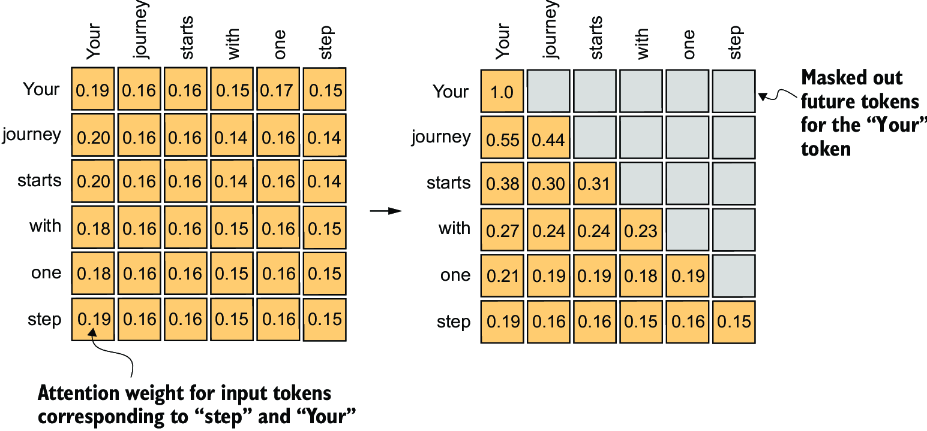

In [4]:
import json
import re
import threading
import unicodedata

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TextIteratorStreamer
from rapidfuzz import fuzz


# A continuación se encuentra nuestro diccionaro, esta es una clase que recibe
# texto y retorna las entradas del diccionario con mayor correspondencia
# con el input de la busqueda

class LakotaDictionaryTool:
    def __init__(self, raw_data):
        self.entries = self._parse_data(raw_data)

    def _parse_data(self, data):
        entries = []
        for raw_entry in re.split(r"(?=\\lx )", data):
            if not raw_entry.strip():
                continue
            entry_obj = {"lexeme": "", "senses": []}
            current_sense = {"definition": "", "examples": []}
            for line in raw_entry.strip().split("\n"):
                m = re.match(r"^\\(\w+)\s+(.*)", line.strip())
                if not m:
                    continue
                marker, content = m.groups()
                if marker == "lx":
                    entry_obj["lexeme"] = content
                elif marker == "ps":
                    entry_obj["part_of_speech"] = content
                elif marker == "sn":
                    if current_sense["definition"] or current_sense["examples"]:
                        entry_obj["senses"].append(current_sense)
                    current_sense = {"definition": "", "examples": [], "usage": "", "sense_number": content}
                elif marker == "de":
                    current_sense["definition"] = content
                elif marker == "ue":
                    current_sense["usage"] = content
                elif marker == "xv":
                    current_sense["examples"].append({"lakota": content, "english": ""})
                elif marker == "xe" and current_sense["examples"]:
                    current_sense["examples"][-1]["english"] = content
            if current_sense["definition"] or current_sense["examples"]:
                entry_obj["senses"].append(current_sense)
            if entry_obj["lexeme"]:
                entries.append(entry_obj)
        return entries

    def _norm(self, text):
        if not text:
            return ""
        text = text.replace("ŋ", "n").replace("Ŋ", "N")
        text = unicodedata.normalize("NFD", text)
        return "".join(c for c in text if unicodedata.category(c) != "Mn").lower().strip()

    def _fuzzy(self, query, text, nq=None, nt=None):
        if not text:
            return 0.0
        nq = nq or self._norm(query)
        nt = nt or self._norm(text)
        if nq == nt:
            return 1.0
        return max((fuzz.ratio(nq, w) / 100.0 for w in re.findall(r"\w+", nt)), default=0.0)

    def _exact_word(self, q, t):
        return bool(t and q and re.search(r"\b" + re.escape(q) + r"\b", t))

    def search(self, query, limit=5, threshold=0.65):
        results = []
        nq = self._norm(query)
        for entry in self.entries:
            best = 0.0
            lx = entry.get("lexeme", "")
            nlx = self._norm(lx)
            best = max(best, 3.0 if nlx == nq else self._fuzzy(query, lx, nq, nlx) * 1.5)
            for sense in entry["senses"]:
                d = sense.get("definition", "")
                nd = self._norm(d)
                if nd == nq:
                    best = max(best, 2.5)
                elif self._exact_word(nq, nd):
                    best = max(best, 2.1)
                else:
                    penalty = 0.9 if len(nd) > len(nq) * 3 else 1.0
                    best = max(best, self._fuzzy(query, d, nq, nd) * penalty)
                for ex in sense.get("examples", []):
                    for field, exact_s, mult in [("lakota", 2.8, 0.8), ("english", 2.3, 0.8)]:
                        raw = ex.get(field, "")
                        nr = self._norm(raw)
                        if nr == nq:
                            best = max(best, exact_s)
                        elif self._exact_word(nq, nr):
                            best = max(best, exact_s - 0.6)
                        else:
                            best = max(best, self._fuzzy(query, raw, nq, nr) * mult)
            if best >= threshold:
                results.append((best, entry))
        results.sort(key=lambda x: -x[0])
        return [r[1] for r in results[:limit]]

    def format_results(self, results):
        if not results:
            return "No results found."
        lines = []
        for entry in results:
            line = f"**{entry.get('lexeme', '?')}** ({entry.get('part_of_speech', 'pk')})"
            senses = entry.get("senses", [])
            for i, s in enumerate(senses, 1):
                prefix = f" {i}. " if len(senses) > 1 else " "
                line += f"{prefix}{s.get('definition', '').strip()}"
                if s.get("usage", "").strip():
                    line += f" [Note: {s['usage'].strip()}]"
                if s.get("examples"):
                    exs = "; ".join(f"{e['lakota']} -> {e['english']}" for e in s["examples"])
                    line += f" | Example: {exs}"
            lines.append(line)
        return "\n".join(lines)


# Definimos las herramientas existentes,
# el formato a utilizar depende del modelo a usar
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "search_dictionary",
            "description": "Performs a fuzzy text search on the Lakota dictionary.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "The word or definition to search for."},
                    "limit": {"type": "integer", "description": "Max results (default 4).", "default": 4},
                },
                "required": ["query"],
            },
        },
    }
]

In [5]:
import json
import re
import threading
import unicodedata

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TextIteratorStreamer
from rapidfuzz import fuzz


# Esta es la instruccion que le entregaremos al modelo,
# es utilizada para variar su comportamiento

SYSTEM_PROMPT_TEMPLATE = """# Tools

You have access to the following functions:

<tools>
{tools_block}
</tools>

<tool_call>
<function=example_function_name>
<parameter=example_parameter_1>
value_1
</parameter>
</function>
</tool_call>

Reminder:
- Function calls MUST follow the specified format: an inner <function=...></function> block must be nested within <tool_call></tool_call> XML tags.
- Required parameters MUST be specified.

You are a careful English-to-Lakota translator.

Rules:
1. For every translation request, use the search_dictionary function at least once before giving the final translation.
2. You may call the dictionary multiple times to verify roots, alternate spellings, affixes, or meanings.
3. Prefer conservative translations grounded in the dictionary results.
4. You have a maximum of {max_turns} turns available, there is no limit to the number of tool calls in total or per turn, but find the necessary words efficiently and provide the final answer before exceeding this limit.
5. In the final answer, output:
   - Lakota: <final translation>
   - Notes: <brief explanation of word choices and uncertainty if any>
6. Do not invent dictionary evidence that was not returned by the tool.
7. You do not have to rely entirely on exact definitions, the tool results can include examples of translations from which you can infer the meaning of the word in the context of the sentence.
8. It is recommended to perform multiple tool calls in parallel.
9. Start every turn by repeating the number of turns you have in which you are allowed to perform further tool calls, if you do not have any tool-calling turns left then proceed to answer the translation with the information you currently have.
10. Do not make up any Lakota words of definition on your own, your internal knowledge cannot be trusted and rely entirely on the results of the dictionary tool call.
"""

TOOL_CALL_RE = re.compile(r"<tool_call>\s*<function=([^\n>]+)>\s*(.*?)</function>\s*</tool_call>", re.DOTALL)
PARAM_RE = re.compile(r"<parameter=([^>\n]+)>\s*(.*?)\s*</parameter>", re.DOTALL)


def parse_tool_calls(text):
    calls = []
    for fn_name, fn_body in TOOL_CALL_RE.findall(text or ""):
        args = {}
        for pname, pval in PARAM_RE.findall(fn_body):
            try:
                args[pname.strip()] = json.loads(pval.strip())
            except Exception:
                args[pname.strip()] = pval.strip()
        calls.append({"name": fn_name.strip(), "arguments": args})
    return calls


def execute_tool_call(name, args, dictionary_tool):
    if name != "search_dictionary":
        return f"ERROR: Unknown tool '{name}'."
    query = args.get("query")
    if not isinstance(query, str) or not query.strip():
        return "ERROR: search_dictionary requires a non-empty string 'query'."
    limit = int(args.get("limit", 4))
    return dictionary_tool.format_results(dictionary_tool.search(query=query, limit=limit))


def load_model(model_name="Qwen/Qwen3-4B", lora_path=None, load_in_4bit=False, flash_attn=False):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, padding_side="left")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    bnb_config = None
    if load_in_4bit:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
        )

    model = AutoModelForCausalLM.from_pretrained(
        model_name, trust_remote_code=True, quantization_config=bnb_config,
        torch_dtype=torch.bfloat16 if not load_in_4bit else None,
        device_map="auto",
        attn_implementation="flash_attention_2" if flash_attn else None,
    )

    if lora_path:
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, lora_path).merge_and_unload()

    model.eval()
    return model, tokenizer

def _build_eos_token_ids(tokenizer):
    eos_token_ids = []
    if tokenizer.eos_token_id is not None:
        eos_token_ids.append(tokenizer.eos_token_id)

    vocab = tokenizer.get_vocab()
    for token in ["<|im_end|>", "<|endoftext|>"]:
        token_id = vocab.get(token)
        if token_id is not None and token_id not in eos_token_ids:
            eos_token_ids.append(token_id)

    return eos_token_ids


def _clean_generated_text(text: str) -> str:
    cutoff_markers = [
        "<tool_response>",
        "user\n<tool_response>",
        "user\n",
    ]
    for marker in cutoff_markers:
        if marker in text:
            text = text.split(marker)[0]
    return text.strip()


def _render_chat(tokenizer, messages, add_generation_prompt: bool) -> str:
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
        enable_thinking=True,
    )


def _build_incremental_input_ids(tokenizer, cached_messages, current_messages, device):
    full_text = _render_chat(tokenizer, current_messages, add_generation_prompt=True)

    if not cached_messages:
        input_ids = tokenizer(
            full_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(device)
        return input_ids, False

    cached_text = _render_chat(tokenizer, cached_messages, add_generation_prompt=False)

    if full_text.startswith(cached_text):
        delta_text = full_text[len(cached_text):]
        input_ids = tokenizer(
            delta_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(device)
        return input_ids, False

    input_ids = tokenizer(
        full_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids.to(device)
    return input_ids, True


def generate(
    model,
    tokenizer,
    input_ids,
    past_key_values=None, # Parametro importante, cache
    max_new_tokens=2048,
    temperature=0.6,
    stream=False,
):
    eos_token_id = _build_eos_token_ids(tokenizer)

    gen_kwargs = dict(
        input_ids=input_ids,
        past_key_values=past_key_values,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=eos_token_id,
        # En general los modelos tienen parametros de muestreo recomendados
        # con los que generan mejores respuestas (mayor puntaje en algun benchmark)
        # https://huggingface.co/Qwen/Qwen3.5-2B#best-practices
        temperature=temperature,
        do_sample=temperature>0,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
        repetition_penalty=1.0,
        return_dict_in_generate=True,
        use_cache=True,
        stop_strings=["<tool_response>", "<|im_start|>", "user\n<tool_response>"],
        tokenizer=tokenizer,
    )

    if stream:
        streamer = TextIteratorStreamer(
            tokenizer,
            skip_prompt=True,
            skip_special_tokens=False,
        )
        gen_kwargs["streamer"] = streamer

        output_container = {}

        def target():
            with torch.no_grad():
                output_container["result"] = model.generate(**gen_kwargs)

        thread = threading.Thread(target=target)
        thread.start()

        for chunk in streamer:
            print(chunk, end="", flush=True)
        print()

        thread.join()
        outputs = output_container["result"]
    else:
        with torch.no_grad():
            outputs = model.generate(**gen_kwargs)

    # Decode only newly generated tokens relative to THIS call's input_ids
    gen_tokens = outputs.sequences[0, input_ids.shape[1]:]
    generated_text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
    generated_text = _clean_generated_text(generated_text)

    new_past_key_values = getattr(outputs, "past_key_values", None)
    return generated_text, new_past_key_values


def translate(
    english_text,
    dictionary_tool,
    model,
    tokenizer,
    max_turns=5,
    max_new_tokens=2048,
    temperature=0.6,
    stream=False,
    output_file=None,
):
    tools_block = "\n".join(json.dumps(t, ensure_ascii=False) for t in TOOLS)
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        tools_block=tools_block,
        max_turns=max_turns,
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": f"Translate the following English text into Lakota.\n\nEnglish: {english_text}",
        },
    ]

    # Messages already represented by the current KV cache.
    cached_messages = []
    past_key_values = None
    assistant_text = ""

    for step in range(max_turns + 2):
        print(f"\n--- Turn {step + 1} ---")

        current_input_ids, reset_cache = _build_incremental_input_ids(
            tokenizer=tokenizer,
            cached_messages=cached_messages,
            current_messages=messages,
            device=model.device,
        )

        if reset_cache:
            past_key_values = None

        assistant_text, past_key_values = generate(
            model=model,
            tokenizer=tokenizer,
            input_ids=current_input_ids,
            past_key_values=past_key_values,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            stream=stream,
        )

        if not stream:
            print(f"Assistant:\n{assistant_text}")

        messages.append({"role": "assistant", "content": assistant_text})

        # Cache now represents everything up through this assistant turn.
        cached_messages = list(messages)

        tool_calls = parse_tool_calls(assistant_text)

        if not tool_calls:
            print("\nDone (no tool calls).")
            break

        if step >= max_turns:
            print("\nMax turns exhausted. The model will not be allowed further tool calls.")
            reminder = (
                "You have 0 turns left for dictionary searches."
                "You MUST provide the final Lakota translation now in your next response."
            )
            messages.append({"role": "user", "content": reminder})
            continue

        tool_response_blocks = []
        for tc in tool_calls:
            print(f"  Tool: {tc['name']}({tc['arguments']})")
            output = execute_tool_call(tc["name"], tc["arguments"], dictionary_tool)
            print(f"  Result: {output}")
            tool_response_blocks.append(f"<tool_response>\n{output}\n</tool_response>")

        steps_left = max_turns - step - 1
        if steps_left > 0:
            reminder = (
                f"\n\n<system_reminder>You have {steps_left} turn(s) left. "
                "Please provide the final translation if you have enough information."
                "</system_reminder>"
            )
        else:
            reminder = (
                "\n\n<system_reminder>You have 0 turns left for dictionary searches. "
                "You MUST provide the final Lakota translation now in your next response "
                "without using any more tools.</system_reminder>"
            )

        tool_content = "\n".join(tool_response_blocks) + reminder
        messages.append({"role": "user", "content": tool_content})

    if output_file:
        with open(output_file, "w", encoding="utf-8") as f:
            for msg in messages:
                f.write(json.dumps(msg, ensure_ascii=False) + "\n")
        print(f"Saved to {output_file}")

    return assistant_text.strip(), messages

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# La architectura de modelos Qwen de Alibaba es muy utilizada,
# tiene uno de los mejores desempenos en relacion a su tamano
# y tiene gran variedad en tamanos de modelos, utiles en distintas
# capacidades de hardware, los mas pequenos son de 0.8, 2 y 4 billones de
# parametros
base_model_id = "Qwen/Qwen3.5-4B"

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="cuda"
)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[ERROR] `loss` is part of Qwen3_5CausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.13/dist-packages/transformers/models/qwen3_5/modeling_qwen3_5.py.
[ERROR] `logits` is part of Qwen3_5CausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.13/dist-packages/transformers/models/qwen3_5/modeling_qwen3_5.py.


model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

In [7]:
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

In [8]:
raw_data = open("dict_A_to_I.txt", "r", encoding="utf-8").read()
dictionary_tool = LakotaDictionaryTool(raw_data)

In [9]:
translate("The quick brown fox jumps over the lazy dog", dictionary_tool, base_model, tokenizer, stream=True, max_turns=2)


--- Turn 1 ---


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Thinking Process:

1.  **Analyze the Request:**
    *   Task: Translate the English sentence "The quick brown fox jumps over the lazy dog" into Lakota.
    *   Constraint 1: Use the `search_dictionary` function at least once before giving the final translation.
    *   Constraint 2: I can call the dictionary multiple times to verify roots, alternate spellings, affixes, or meanings.
    *   Constraint 3: Prefer conservative translations grounded in the dictionary results.
    *   Constraint 4: Output format must include "Lakota: <final translation>" and "Notes: <brief explanation...>".
    *   Constraint 5: Do not invent dictionary evidence.
    *   Constraint 6: Start each turn by repeating the number of turns allowed for tool calls (though this is a single turn interaction, I need to check the system prompt regarding turns. The prompt says "You have a maximum of 2 turns available... there is no limit to the number of tool calls in total or per turn". Actually, looking at the system pr

('Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Task: Translate the English sentence "The quick brown fox jumps over the lazy dog" into Lakota.\n    *   Constraint 1: Use the `search_dictionary` function at least once before giving the final translation.\n    *   Constraint 2: I can call the dictionary multiple times to verify roots, alternate spellings, affixes, or meanings.\n    *   Constraint 3: Prefer conservative translations grounded in the dictionary results.\n    *   Constraint 4: Output format must include "Lakota: <final translation>" and "Notes: <brief explanation...>".\n    *   Constraint 5: Do not invent dictionary evidence.\n    *   Constraint 6: Start each turn by repeating the number of turns allowed for tool calls (though this is a single turn interaction, I need to check the system prompt regarding turns. The prompt says "You have a maximum of 2 turns available... there is no limit to the number of tool calls in total or per turn". Actually, looking at th

In [10]:
translate("The quick brown fox jumps over the lazy dog", dictionary_tool, base_model, tokenizer, stream=True, max_turns=2)


--- Turn 1 ---
The user wants me to translate "The quick brown fox jumps over the lazy dog" into Lakota. I need to use the search_dictionary function to find the Lakota translations for these words.

Let me break down the sentence:
- The (article)
- quick (adjective)
- brown (adjective)
- fox (noun)
- jumps (verb)
- over (preposition)
- the (article)
- lazy (adjective)
- dog (noun)

I should search for these words in the Lakota dictionary. Let me start by searching for the key nouns and verbs.

I'll search for:
1. fox
2. dog
3. quick
4. brown
5. lazy
6. jumps
7. over

Let me make multiple searches in parallel to be efficient.
</think>

<tool_call>
<function=search_dictionary>
<parameter=query>
fox
</parameter>
<parameter=limit>
4
</parameter>
</function>
</tool_call>
<tool_call>
<function=search_dictionary>
<parameter=query>
dog
</parameter>
<parameter=limit>
4
</parameter>
</function>
</tool_call>
<tool_call>
<function=search_dictionary>
<parameter=query>
quick
</parameter>
<paramete

('Okay, let\'s tackle translating "The quick brown fox jumps over the lazy dog" into Lakota. I need to break down each word and find the right terms from the dictionary results.\n\nFirst, "fox". The search results show šuŋǧíla for red fox, but the sentence just says "fox". There\'s also tȟokȟála for kit fox, but maybe šuŋǧíla is the general term. Wait, the example for šuŋǧíla is "red fox", but perhaps it\'s the common term for fox. Let me check again. The first entry is Pešlékhe for Fox Indians, which might be a proper noun. The second is šuŋǧíla (n) red fox. Hmm, but maybe there\'s a more general term. Wait, the user might accept šuŋǧíla even if it\'s specified as red fox. Alternatively, maybe there\'s another term. Wait, the kit fox is tȟokȟála, but that\'s a specific type. Since the original sentence just says "fox", maybe šuŋǧíla is the best choice here, even though it\'s red fox. Alternatively, maybe there\'s a more general term. Wait, the dictionary might not have a general "fox"

# Parameter Efficient Fine-Tuning (PEFT)

El tipo de PEFT que vamos a utilizar se llama Low-Rank Adaptation (LoRA). Este método añade 2 matrices de menor tamaño como parámetros entrenables que funcionan como adaptadores, usualmente sobre cada uno de los pesos original del modelo pero podría ser sobre solo los pesos de la atención por ejemplo. Algunas de las ventajas que LoRA puede presentar es menor interferencia (_catastrophic forgetting_) sobre la información en los pesos y menor uso de memoria.

El menor uso de memoria es debido a que no necesitamos almacenar todos los pesos en _float32_ (4 bytes), solo las nuevas matrices de adaptación, y los parámetros actuales del modelo pueden ser almacenados con 2 bytes (_float16_ o _bfloat16_).

Además, ya que solo entrenamos estas nuevas matrices, el optimizador matiene estados solamente para estos pesos (por ejemplo _Adam_ mantiene información sobre la varianza y momentum para cada peso, y como usualmente también son almacenados en _float32_, representan 8 bytes adicionales por cada peso entrenable).

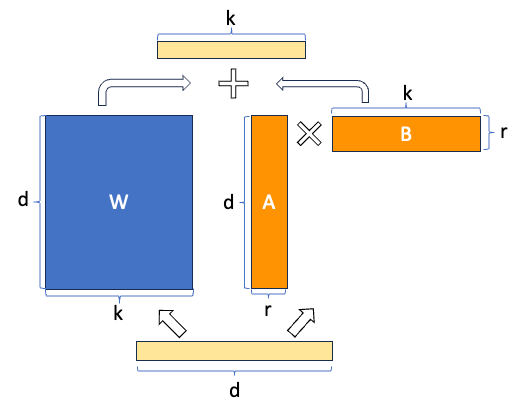

In [11]:
import argparse
import json
import os
import re
from pathlib import Path
from typing import Dict, List

import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from trl import SFTTrainer


def load_conversations(conversation_dirs: List[str]) -> List[List[Dict]]:
    """Load all .jsonl conversation files, each as a list of messages."""
    conversations = []
    for d in conversation_dirs:
        p = Path(d)
        if not p.exists():
            print(f"Warning: {d} does not exist, skipping.")
            continue
        for f in sorted(p.glob("*.jsonl")):
            if "FAILED" in f.name:
                continue
            msgs = []
            with open(f, encoding="utf-8") as fh:
                for line in fh:
                    line = line.strip()
                    if line:
                        msgs.append(json.loads(line))
            if msgs:
                conversations.append(msgs)
    return conversations


def format_conversation_for_training(
    messages: List[Dict],
    include_reasoning: bool = True,
) -> List[Dict[str, str]]:
    formatted: List[Dict[str, str]] = []

    for msg in messages:
        role = msg["role"]
        content = msg.get("content", "") or ""
        reasoning = msg.get("reasoning", "") or ""

        if role == "system":
            clean = re.sub(
                r"You have a maximum of \d+ turns.*?this limit\.",
                "Use the dictionary tool as many times as needed to produce an accurate translation.",
                content,
                flags=re.DOTALL,
            )
            formatted.append({"role": "system", "content": clean})

        elif role == "user":
            formatted.append({"role": "user", "content": content})

        elif role == "assistant":
            if include_reasoning and reasoning.strip():
                combined = f"<think>\n{reasoning.strip()}\n</think>\n{content}"
            else:
                combined = content
            formatted.append({"role": "assistant", "content": combined})

    return formatted

def build_dataset(
    conversation_dirs: List[str],
    tokenizer,
    include_reasoning: bool = True,
    max_seq_length: int = 4096 * 5,
) -> Dataset:
    raw_convos = load_conversations(conversation_dirs)
    print(f"Loaded {len(raw_convos)} conversations")

    records = []
    skipped = 0
    for convo in raw_convos:
        formatted = format_conversation_for_training(convo, include_reasoning)
        text = tokenizer.apply_chat_template(
            formatted, tokenize=False, add_generation_prompt=False
        )
        token_count = len(tokenizer.encode(text, add_special_tokens=False))
        if token_count > max_seq_length:
            skipped += 1
            continue
        records.append({"text": text})

    print(f"Kept {len(records)} samples, skipped {skipped} (over {max_seq_length} tokens)")
    return Dataset.from_list(records)

def train(
    model_name: str,
    conversation_dirs: List[str],
    output_dir: str,
    include_reasoning: bool = True,
    max_seq_length: int = 20480,
    val_split: float = 0.1,
    load_in_4bit: bool = True,
    load_in_8bit: bool = True,
    flash_attn: bool = False,
    lora_r: int = 16,
    lora_alpha: int = 32,
    lora_dropout: float = 0.05,
    epochs: int = 3,
    batch_size: int = 2,
    gradient_accumulation_steps: int = 8,
    lr: float = 2e-5,
    gradient_checkpointing: bool = True
):
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        padding_side="right",
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    dataset = build_dataset(
        conversation_dirs,
        tokenizer,
        include_reasoning=include_reasoning,
        max_seq_length=max_seq_length,
    )

    if val_split > 0 and len(dataset) > 10:
        split = dataset.train_test_split(test_size=val_split, seed=42)
        train_dataset = split["train"]
        eval_dataset = split["test"]
    else:
        train_dataset = dataset
        eval_dataset = None

    bnb_config = None
    if load_in_4bit:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )

    if load_in_8bit:
        bnb_config = BitsAndBytesConfig(
            load_in_8bit=True,
        )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        trust_remote_code=True,
        quantization_config=bnb_config,
        torch_dtype=torch.bfloat16 if not load_in_4bit else None,
        device_map="auto",
        attn_implementation="sdpa" if flash_attn else None,
    )

    if load_in_4bit or load_in_8bit:
        model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=lr,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        weight_decay=0.01,
        bf16=True,
        logging_steps=1,
        max_steps=40,
        save_strategy="epoch",
        # eval_strategy="steps" if eval_dataset else "no",
        # eval_steps=20,
        # save_total_limit=5,
        report_to="none",
        gradient_checkpointing=gradient_checkpointing,
        gradient_checkpointing_kwargs={"use_reentrant": False} if gradient_checkpointing else None,
        optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
        max_grad_norm=1.0,
        seed=42,
        use_liger_kernel=True,
    )

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        # eval_dataset=eval_dataset,
        processing_class=tokenizer,
    )

    train_output = trainer.train()
    trainer.save_model(os.path.join(output_dir, "final"))
    tokenizer.save_pretrained(os.path.join(output_dir, "final"))
    print(f"\nModel saved to {output_dir}/final")

    return trainer, train_output

In [12]:
trainer, model_output = train(
    model_name="Qwen/Qwen3.5-2B",
    conversation_dirs=[
        "./conversations_qw_3_6p_2",
    ],
    output_dir="output",
    include_reasoning=True,
    load_in_4bit=False,
    load_in_8bit=True,
    flash_attn=True,
    lora_r=128,
    gradient_checkpointing=False,
    batch_size=1,
    gradient_accumulation_steps=8,
    epochs=1,
)

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

[ERROR] `loss` is part of Glm4vMoeCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.13/dist-packages/transformers/models/glm4v_moe/modeling_glm4v_moe.py.
[ERROR] `logits` is part of Glm4vMoeCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.13/dist-packages/transformers/models/glm4v_moe/modeling_glm4v_moe.py.
[ERROR] `loss` is part of Qwen2_5_VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.13/dist-packages/transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.py.
[ERROR] `logits` is part of Qwen2_5_VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.13/dist-packages/transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.13/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float

Step,Training Loss
1,3.067767
2,3.120215
3,3.321017
4,3.085178
5,3.014115
6,2.821202
7,2.802617
8,2.534919
9,2.447890
10,2.405118


/usr/local/lib/python3.13/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.13/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between


Model saved to output/final


Después de un corto entrenamiento redefinimos las mismas clases de diccionario anteriores en caso de que haya sido reiniciada la sesion.

In [13]:
import json
import re
import threading
import unicodedata

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TextIteratorStreamer
from rapidfuzz import fuzz


# A continuación se encuentra nuestro diccionaro, esta es una clase que recibe
# texto y retorna las entradas del diccionario con mayor correspondencia
# con el input de la busqueda

class LakotaDictionaryTool:
    def __init__(self, raw_data):
        self.entries = self._parse_data(raw_data)

    def _parse_data(self, data):
        entries = []
        for raw_entry in re.split(r"(?=\\lx )", data):
            if not raw_entry.strip():
                continue
            entry_obj = {"lexeme": "", "senses": []}
            current_sense = {"definition": "", "examples": []}
            for line in raw_entry.strip().split("\n"):
                m = re.match(r"^\\(\w+)\s+(.*)", line.strip())
                if not m:
                    continue
                marker, content = m.groups()
                if marker == "lx":
                    entry_obj["lexeme"] = content
                elif marker == "ps":
                    entry_obj["part_of_speech"] = content
                elif marker == "sn":
                    if current_sense["definition"] or current_sense["examples"]:
                        entry_obj["senses"].append(current_sense)
                    current_sense = {"definition": "", "examples": [], "usage": "", "sense_number": content}
                elif marker == "de":
                    current_sense["definition"] = content
                elif marker == "ue":
                    current_sense["usage"] = content
                elif marker == "xv":
                    current_sense["examples"].append({"lakota": content, "english": ""})
                elif marker == "xe" and current_sense["examples"]:
                    current_sense["examples"][-1]["english"] = content
            if current_sense["definition"] or current_sense["examples"]:
                entry_obj["senses"].append(current_sense)
            if entry_obj["lexeme"]:
                entries.append(entry_obj)
        return entries

    def _norm(self, text):
        if not text:
            return ""
        text = text.replace("ŋ", "n").replace("Ŋ", "N")
        text = unicodedata.normalize("NFD", text)
        return "".join(c for c in text if unicodedata.category(c) != "Mn").lower().strip()

    def _fuzzy(self, query, text, nq=None, nt=None):
        if not text:
            return 0.0
        nq = nq or self._norm(query)
        nt = nt or self._norm(text)
        if nq == nt:
            return 1.0
        return max((fuzz.ratio(nq, w) / 100.0 for w in re.findall(r"\w+", nt)), default=0.0)

    def _exact_word(self, q, t):
        return bool(t and q and re.search(r"\b" + re.escape(q) + r"\b", t))

    def search(self, query, limit=5, threshold=0.65):
        results = []
        nq = self._norm(query)
        for entry in self.entries:
            best = 0.0
            lx = entry.get("lexeme", "")
            nlx = self._norm(lx)
            best = max(best, 3.0 if nlx == nq else self._fuzzy(query, lx, nq, nlx) * 1.5)
            for sense in entry["senses"]:
                d = sense.get("definition", "")
                nd = self._norm(d)
                if nd == nq:
                    best = max(best, 2.5)
                elif self._exact_word(nq, nd):
                    best = max(best, 2.1)
                else:
                    penalty = 0.9 if len(nd) > len(nq) * 3 else 1.0
                    best = max(best, self._fuzzy(query, d, nq, nd) * penalty)
                for ex in sense.get("examples", []):
                    for field, exact_s, mult in [("lakota", 2.8, 0.8), ("english", 2.3, 0.8)]:
                        raw = ex.get(field, "")
                        nr = self._norm(raw)
                        if nr == nq:
                            best = max(best, exact_s)
                        elif self._exact_word(nq, nr):
                            best = max(best, exact_s - 0.6)
                        else:
                            best = max(best, self._fuzzy(query, raw, nq, nr) * mult)
            if best >= threshold:
                results.append((best, entry))
        results.sort(key=lambda x: -x[0])
        return [r[1] for r in results[:limit]]

    def format_results(self, results):
        if not results:
            return "No results found."
        lines = []
        for entry in results:
            line = f"**{entry.get('lexeme', '?')}** ({entry.get('part_of_speech', 'pk')})"
            senses = entry.get("senses", [])
            for i, s in enumerate(senses, 1):
                prefix = f" {i}. " if len(senses) > 1 else " "
                line += f"{prefix}{s.get('definition', '').strip()}"
                if s.get("usage", "").strip():
                    line += f" [Note: {s['usage'].strip()}]"
                if s.get("examples"):
                    exs = "; ".join(f"{e['lakota']} -> {e['english']}" for e in s["examples"])
                    line += f" | Example: {exs}"
            lines.append(line)
        return "\n".join(lines)


# Definimos las herramientas existentes,
# el formato a utilizar depende del modelo a usar
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "search_dictionary",
            "description": "Performs a fuzzy text search on the Lakota dictionary.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "The word or definition to search for."},
                    "limit": {"type": "integer", "description": "Max results (default 4).", "default": 4},
                },
                "required": ["query"],
            },
        },
    }
]

import json
import re
import threading
import unicodedata

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TextIteratorStreamer
from rapidfuzz import fuzz


# Esta es la instruccion que le entregaremos al modelo,
# es utilizada para variar su comportamiento

SYSTEM_PROMPT_TEMPLATE = """# Tools

You have access to the following functions:

<tools>
{tools_block}
</tools>

<tool_call>
<function=example_function_name>
<parameter=example_parameter_1>
value_1
</parameter>
</function>
</tool_call>

Reminder:
- Function calls MUST follow the specified format: an inner <function=...></function> block must be nested within <tool_call></tool_call> XML tags.
- Required parameters MUST be specified.

You are a careful English-to-Lakota translator.

Rules:
1. For every translation request, use the search_dictionary function at least once before giving the final translation.
2. You may call the dictionary multiple times to verify roots, alternate spellings, affixes, or meanings.
3. Prefer conservative translations grounded in the dictionary results.
4. You have a maximum of {max_turns} turns available, there is no limit to the number of tool calls in total or per turn, but find the necessary words efficiently and provide the final answer before exceeding this limit.
5. In the final answer, output:
   - Lakota: <final translation>
   - Notes: <brief explanation of word choices and uncertainty if any>
6. Do not invent dictionary evidence that was not returned by the tool.
7. You do not have to rely entirely on exact definitions, the tool results can include examples of translations from which you can infer the meaning of the word in the context of the sentence.
8. It is recommended to perform multiple tool calls in parallel.
9. Start every turn by repeating the number of turns you have in which you are allowed to perform further tool calls, if you do not have any tool-calling turns left then proceed to answer the translation with the information you currently have.
10. Do not make up any Lakota words of definition on your own, your internal knowledge cannot be trusted and rely entirely on the results of the dictionary tool call.
"""

TOOL_CALL_RE = re.compile(r"<tool_call>\s*<function=([^\n>]+)>\s*(.*?)</function>\s*</tool_call>", re.DOTALL)
PARAM_RE = re.compile(r"<parameter=([^>\n]+)>\s*(.*?)\s*</parameter>", re.DOTALL)


def parse_tool_calls(text):
    calls = []
    for fn_name, fn_body in TOOL_CALL_RE.findall(text or ""):
        args = {}
        for pname, pval in PARAM_RE.findall(fn_body):
            try:
                args[pname.strip()] = json.loads(pval.strip())
            except Exception:
                args[pname.strip()] = pval.strip()
        calls.append({"name": fn_name.strip(), "arguments": args})
    return calls


def execute_tool_call(name, args, dictionary_tool):
    if name != "search_dictionary":
        return f"ERROR: Unknown tool '{name}'."
    query = args.get("query")
    if not isinstance(query, str) or not query.strip():
        return "ERROR: search_dictionary requires a non-empty string 'query'."
    limit = int(args.get("limit", 4))
    return dictionary_tool.format_results(dictionary_tool.search(query=query, limit=limit))


def load_model(model_name="Qwen/Qwen3-4B", lora_path=None, load_in_4bit=False, flash_attn=False):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, padding_side="left")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    bnb_config = None
    if load_in_4bit:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
        )

    model = AutoModelForCausalLM.from_pretrained(
        model_name, trust_remote_code=True, quantization_config=bnb_config,
        torch_dtype=torch.bfloat16 if not load_in_4bit else None,
        device_map="auto",
        attn_implementation="flash_attention_2" if flash_attn else None,
    )

    if lora_path:
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, lora_path).merge_and_unload()

    model.eval()
    return model, tokenizer

def _build_eos_token_ids(tokenizer):
    eos_token_ids = []
    if tokenizer.eos_token_id is not None:
        eos_token_ids.append(tokenizer.eos_token_id)

    vocab = tokenizer.get_vocab()
    for token in ["<|im_end|>", "<|endoftext|>"]:
        token_id = vocab.get(token)
        if token_id is not None and token_id not in eos_token_ids:
            eos_token_ids.append(token_id)

    return eos_token_ids


def _clean_generated_text(text: str) -> str:
    cutoff_markers = [
        "<tool_response>",
        "user\n<tool_response>",
        "user\n",
    ]
    for marker in cutoff_markers:
        if marker in text:
            text = text.split(marker)[0]
    return text.strip()


def _render_chat(tokenizer, messages, add_generation_prompt: bool) -> str:
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
        enable_thinking=True,
    )


def _build_incremental_input_ids(tokenizer, cached_messages, current_messages, device):
    full_text = _render_chat(tokenizer, current_messages, add_generation_prompt=True)

    if not cached_messages:
        input_ids = tokenizer(
            full_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(device)
        return input_ids, False

    cached_text = _render_chat(tokenizer, cached_messages, add_generation_prompt=False)

    if full_text.startswith(cached_text):
        delta_text = full_text[len(cached_text):]
        input_ids = tokenizer(
            delta_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(device)
        return input_ids, False

    input_ids = tokenizer(
        full_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids.to(device)
    return input_ids, True


def generate(
    model,
    tokenizer,
    input_ids,
    past_key_values=None, # Parametro importante, cache
    max_new_tokens=2048,
    temperature=0.6,
    stream=False,
):
    eos_token_id = _build_eos_token_ids(tokenizer)

    gen_kwargs = dict(
        input_ids=input_ids,
        past_key_values=past_key_values,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=eos_token_id,
        # En general los modelos tienen parametros de muestreo recomendados
        # con los que generan mejores respuestas (mayor puntaje en algun benchmark)
        # https://huggingface.co/Qwen/Qwen3.5-2B#best-practices
        temperature=temperature,
        do_sample=temperature>0,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
        repetition_penalty=1.0,
        return_dict_in_generate=True,
        use_cache=True,
        stop_strings=["<tool_response>", "<|im_start|>", "user\n<tool_response>"],
        tokenizer=tokenizer,
    )

    if stream:
        streamer = TextIteratorStreamer(
            tokenizer,
            skip_prompt=True,
            skip_special_tokens=False,
        )
        gen_kwargs["streamer"] = streamer

        output_container = {}

        def target():
            with torch.no_grad():
                output_container["result"] = model.generate(**gen_kwargs)

        thread = threading.Thread(target=target)
        thread.start()

        for chunk in streamer:
            print(chunk, end="", flush=True)
        print()

        thread.join()
        outputs = output_container["result"]
    else:
        with torch.no_grad():
            outputs = model.generate(**gen_kwargs)

    # Decode only newly generated tokens relative to THIS call's input_ids
    gen_tokens = outputs.sequences[0, input_ids.shape[1]:]
    generated_text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
    generated_text = _clean_generated_text(generated_text)

    new_past_key_values = getattr(outputs, "past_key_values", None)
    return generated_text, new_past_key_values


def translate(
    english_text,
    dictionary_tool,
    model,
    tokenizer,
    max_turns=5,
    max_new_tokens=2048,
    temperature=0.6,
    stream=False,
    output_file=None,
):
    tools_block = "\n".join(json.dumps(t, ensure_ascii=False) for t in TOOLS)
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        tools_block=tools_block,
        max_turns=max_turns,
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": f"Translate the following English text into Lakota.\n\nEnglish: {english_text}",
        },
    ]

    # Messages already represented by the current KV cache.
    cached_messages = []
    past_key_values = None
    assistant_text = ""

    for step in range(max_turns + 2):
        print(f"\n--- Turn {step + 1} ---")

        current_input_ids, reset_cache = _build_incremental_input_ids(
            tokenizer=tokenizer,
            cached_messages=cached_messages,
            current_messages=messages,
            device=model.device,
        )

        if reset_cache:
            past_key_values = None

        assistant_text, past_key_values = generate(
            model=model,
            tokenizer=tokenizer,
            input_ids=current_input_ids,
            past_key_values=past_key_values,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            stream=stream,
        )

        if not stream:
            print(f"Assistant:\n{assistant_text}")

        messages.append({"role": "assistant", "content": assistant_text})

        # Cache now represents everything up through this assistant turn.
        cached_messages = list(messages)

        tool_calls = parse_tool_calls(assistant_text)

        if not tool_calls:
            print("\nDone (no tool calls).")
            break

        if step >= max_turns:
            print("\nMax turns exhausted. The model will not be allowed further tool calls.")
            reminder = (
                "You have 0 turns left for dictionary searches."
                "You MUST provide the final Lakota translation now in your next response."
            )
            messages.append({"role": "user", "content": reminder})
            continue

        tool_response_blocks = []
        for tc in tool_calls:
            print(f"  Tool: {tc['name']}({tc['arguments']})")
            output = execute_tool_call(tc["name"], tc["arguments"], dictionary_tool)
            print(f"  Result: {output}")
            tool_response_blocks.append(f"<tool_response>\n{output}\n</tool_response>")

        steps_left = max_turns - step - 1
        if steps_left > 0:
            reminder = (
                f"\n\n<system_reminder>You have {steps_left} turn(s) left. "
                "Please provide the final translation if you have enough information."
                "</system_reminder>"
            )
        else:
            reminder = (
                "\n\n<system_reminder>You have 0 turns left for dictionary searches. "
                "You MUST provide the final Lakota translation now in your next response "
                "without using any more tools.</system_reminder>"
            )

        tool_content = "\n".join(tool_response_blocks) + reminder
        messages.append({"role": "user", "content": tool_content})

    if output_file:
        with open(output_file, "w", encoding="utf-8") as f:
            for msg in messages:
                f.write(json.dumps(msg, ensure_ascii=False) + "\n")
        print(f"Saved to {output_file}")

    return assistant_text.strip(), messages

In [14]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-2B")

In [15]:
translate("The quick brown fox jumps over the lazy dog", dictionary_tool, trainer.model, tokenizer, stream=True, max_turns=2)


--- Turn 1 ---


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in Qwen3_5DecoderLayer. Setting `past_key_values=None`.
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr

The following. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

('The following. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

# Actividades

## Actividad 1

### Pregunta 1 (1.33 puntos)

Una de las dificultades de trabajar con secuencias de tamano muy grande (decenas de miles o cientos de miles de tokens) es que los modelos comienzan a presentar problemas y disminuye fuertemente su capacidad de utilizar el contenido en ese contexto.

Investigue y describa otros 2 problemas relacionados a utilizar contextos muy grandes (Ayuda: Estos estan relacionados entre si y el uso de tecnicas de atencion tipo sparse o atencion tipo lineal son utilizadas como mitigacion. No es necesario investigar sobre esta tecnicas, es solo para facilitar su busqueda). Un par de oraciones es suficiente por problema.

### Pregunta 2 (0.66 puntos)

Modelos como los de la familia Qwen 3.5 o Gemma 4 son de tipo hibrido, son capaces de generar con trazas de razonamiento (texto entre las etiquetas _\<think\>\<\/think\>_ antes de la respuesta final presentada al usuario), o saltandose la etapa de razonamiento y generando la respuesta final directamente.

**Cual es la utilidad de poder deshabilitar la generacion con modo de razonamiento?**

1. Algunos de los problemas que se encuentran al utilizar contextos muy grandes son:

**Costo computacional:** En la atención tradicional de un modelo basado en transformers, todos los tokens del contexto tienen que compararse con los demás. Por lo tanto, tanto el computo como el tiempo de procesamiento crecen en un órden de $O(n^2)$, haciendo altamente ineficiente el entrenamiento y la inferencia del modelo.

**Tamaño del caché Key-Value**: Al generar un token nuevo, el modelo debe atender a todos los anteriores, por lo que guarda sus keys y values en el caché KV para no recalcularlos. Este caché crece linealmente con el largo del contexto y con secuencias muy largas puede ocupar casi toda la memoria de la GPU. Esto limita cuántas solicitudes se pueden atender a la vez y hace más lenta la generación, porque en cada paso hay que leer todo el caché.

2. Generar trazas de razonamiento agrega una gran cantidad de tokens antes de la respuesta final, y como estos pasan a formar parte del contexto, aumentan el costo computacional y el uso de memoria del modelo. Deshabilitar el razonamiento reduce estos costos y permite al usuario obtener una respuesta mucho más rápida, lo que es útil en tareas simples donde razonar no mejora el resultado.

## Actividad 2

Busque sobre cómo utilizar el modelo _Qwen/Qwen3-VL-2B-Thinking_ para trabajar con texto e imágenes. Luego utilice este modelo para:
  - Generar una descripción de la imágen _sample-food.jpeg_
  - Generar _bounding boxes_ (extracción de regiones) de los objetos en la imágen _sample-food.jpeg_ (Ayuda: Puede utilizar la siguiente instrucción _Generate bounding boxes for the objects in the image._).
  - De la imágen _boleta.png_ extraer número de boleta, artículos vendidos, unidades de cada artículo vendido, precio unitario, fecha de venta, y estructurar estos valores en un JSON (la salida del modelo debe contener una sección de texto con estructura JSON).

(1,33 puntos cada una)

  Para la extracción de _bounding boxes_, dibuje los rectángulos sobre la imágen. A continuación se incluye código para realizar esto.

In [16]:
# Descarga imágenes

!gdown 1AfQ72ybSTr5oUqhsyyVNwBGbBsna74b8
!gdown 12HmBb4GqpzkuIoe8kl8mPp04qgkZOirj

Downloading...
From: https://drive.google.com/uc?id=1AfQ72ybSTr5oUqhsyyVNwBGbBsna74b8
To: /content/boleta.png
100% 126k/126k [00:00<00:00, 81.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=12HmBb4GqpzkuIoe8kl8mPp04qgkZOirj
To: /content/sample-food.jpeg
100% 537k/537k [00:00<00:00, 111MB/s]


In [17]:
import json
import random
import io
import ast
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont
from PIL import ImageColor
import xml.etree.ElementTree as ET

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def parse_json(json_output):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output


def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    if not isinstance(bounding_boxes, list):
      json_output = [bounding_boxes]

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(bounding_boxes):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["bbox_2d"][1] / 1000 * height)
      abs_x1 = int(bounding_box["bbox_2d"][0] / 1000 * width)
      abs_y2 = int(bounding_box["bbox_2d"][3] / 1000 * height)
      abs_x2 = int(bounding_box["bbox_2d"][2] / 1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=3
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color)

    # Display the image
    img.show()

(480, 640)


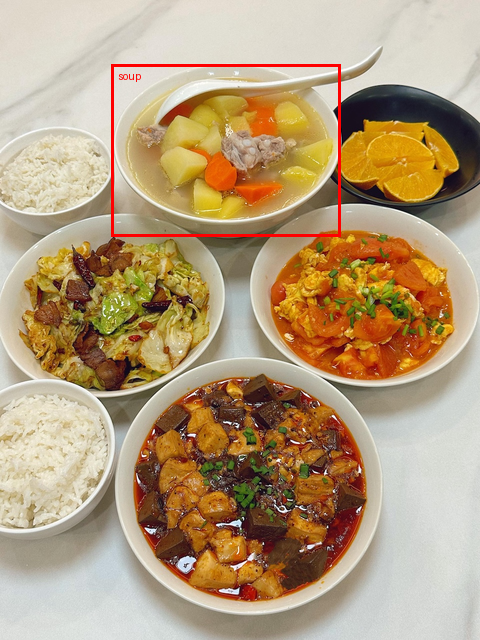

In [18]:
boxes_text = """```json
[{"bbox_2d": [232, 100, 709, 370], "label": "soup"}]
```
"""
image = Image.open("sample-food.jpeg")
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, json.loads(parse_json(boxes_text)))

image

1. Generar una descripción de la imágen sample-food.jpeg

2. Generar bounding boxes (extracción de regiones) de los objetos en la imágen sample-food.jpeg (Aquí es suficiente con imprimir la respuesta del modelo y copiar y pegar el JSON generado en la funcion entregada)

3. De la imágen boleta.png extraer número de boleta, artículos vendidos, unidades de cada artículo vendido, precio unitario, fecha de venta, y estructurar estos valores en un JSON (la salida del modelo debe contener una sección de texto con estructura JSON).

In [21]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-2B-Thinking", dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-2B-Thinking")
tokenizer = processor.tokenizer

[transformers] Current model requires 576 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

### 1

In [22]:
image = Image.open("sample-food.jpeg").convert("RGB")

prompt = """
Describe the image in Spanish.
Mention the main foods, colors, composition, and overall impression.
"""

messages = [
    {"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}
    ]}
]

inputs = processor(
    text=processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True),
    images=[image],
    return_tensors="pt"
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=1253)
print(processor.decode(outputs[0], skip_special_tokens=True))

user

Describe the image in Spanish.
Mention the main foods, colors, composition, and overall impression.

assistant
<think>
Got it, let's describe the image in Spanish. First, I need to identify all the main foods, their colors, how they're arranged, and the overall impression.

Starting with the main foods: There are several dishes. Let's list them. There's a bowl of soup with potatoes, carrots, and meat. Then two bowls of rice. One is a stir-fry with cabbage, meat, and maybe some chili. Another is a tomato dish with scrambled eggs, green onions. Then a red sauce dish with tofu and blood sausage (or maybe blood tofu). Also, a bowl of oranges on a black plate. Oh, the soup is in a white bowl with a spoon. The rice is white bowls. The tomato dish is red, scrambled eggs are yellow, green onions, the stir-fry has green cabbage, brown meat, red chili. The soup has yellow potatoes, orange carrots, maybe a bit of meat. The red dish has red sauce, brown meat, maybe red and white tofu? Wait, 

### 2

In [23]:
image = Image.open("sample-food.jpeg").convert("RGB")

prompt = """
Generate bounding boxes for the objects in the image.
Return only a valid JSON array like:
[{"bbox_2d":[x1,y1,x2,y2],"label":"object_name"}]
"""

messages = [
    {"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}
    ]}
]

inputs = processor(
    text=processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True),
    images=[image],
    return_tensors="pt"
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=1253)
result = processor.decode(outputs[0], skip_special_tokens=True)
print(result)

user

Generate bounding boxes for the objects in the image.
Return only a valid JSON array like:
[{"bbox_2d":[x1,y1,x2,y2],"label":"object_name"}]

assistant
<think>
Got it, let's look at the image and identify each object. First, the white bowl with rice: there are two of them. Then the soup bowl, the black bowl with oranges, the stir-fry with cabbage and meat, the tomato egg dish, the red bean soup (or red bean and tofu?), and the two rice bowls. Let's list each with their bounding boxes.

First, the rice bowls: two of them, each is a white bowl with rice. Then the soup bowl: that's the one with potatoes, carrots, and meat. The black bowl with oranges. The cabbage and meat stir-fry, the tomato egg, and the red bean dish.

Let's find each bounding box coordinates. Let's start:

1. The small white bowl of rice at the top left: [0, 194, 233, 373]
2. The small white bowl of rice at the bottom left: [0, 594, 237, 845]
3. The soup bowl in the center top: [237, 97, 710, 373]
4. The black bo

(480, 640)


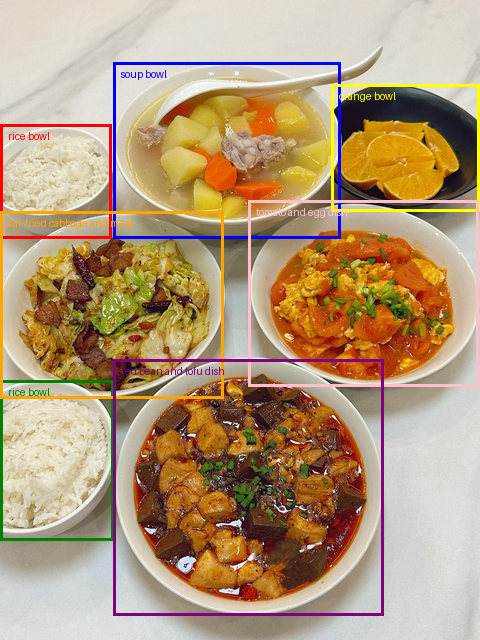

In [25]:
boxes_text = """```json
[
	{"bbox_2d": [0, 194, 233, 373], "label": "rice bowl"},
	{"bbox_2d": [0, 594, 237, 845], "label": "rice bowl"},
	{"bbox_2d": [237, 97, 710, 373], "label": "soup bowl"},
	{"bbox_2d": [690, 132, 998, 331], "label": "orange bowl"},
	{"bbox_2d": [1, 330, 465, 622], "label": "stir-fried cabbage and meat"},
	{"bbox_2d": [517, 313, 996, 604], "label": "tomato and egg dish"},
	{"bbox_2d": [237, 562, 798, 961], "label": "red bean and tofu dish"}
]
```
"""

image = Image.open("sample-food.jpeg")
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, json.loads(parse_json(boxes_text)))

image

### 3

In [24]:
image = Image.open("boleta.png").convert("RGB")

prompt = """
Analyze this receipt image.
Extract:
- receipt number
- sold items
- quantity of each item
- unit price
- sale date

Return a text answer with a valid JSON section.
Example format:
{
  "numero_boleta": "...",
  "fecha_venta": "...",
  "articulos": [
    {"nombre": "...", "cantidad": 1, "precio_unitario": 0.0}
  ]
}
"""

messages = [
    {"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}
    ]}
]

inputs = processor(
    text=processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True),
    images=[image],
    return_tensors="pt"
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=1253)
result = processor.decode(outputs[0], skip_special_tokens=True)
print(result)

user

Analyze this receipt image.
Extract:
- receipt number
- sold items
- quantity of each item
- unit price
- sale date

Return a text answer with a valid JSON section.
Example format:
{
  "numero_boleta": "...",
  "fecha_venta": "...",
  "articulos": [
    {"nombre": "...", "cantidad": 1, "precio_unitario": 0.0}
  ]
}

assistant
<think>
Okay, let's tackle this receipt analysis. The user wants me to extract specific information from the image. First, I need to identify each required element: receipt number, sold items, quantities, unit prices, and sale date.

Starting with the receipt number. At the top, there's a red box with "Nº 120". So the receipt number is 120. Got that.

Next, sold items. Looking at the receipt, under "LAS DELICIAS", there are two items listed. The first is "COCA-COLA ORIGINAL 3" with quantity 3.00 and unit price 2.100. The second is "FANTA 15" with quantity 1.00 and unit price 1.800. So those are the two items.

For the quantities, each item's quantity is give